# Setup

In [1]:
# main
import pandas as pd
import numpy as np
from scipy import stats

# models
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
from sklearn.linear_model import QuantileRegressor
from sklearn.linear_model import LinearRegression

# diagnositcs
import shap
from statsmodels.iolib.summary2 import summary_col
from sklearn.metrics import r2_score

# feature selection
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import TimeSeriesSplit

# transformers
from statsmodels.tsa.tsatools import add_trend
from sklearn.preprocessing import StandardScaler

# tests
from statsmodels.tsa.stattools import adfuller, coint

# charts
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly

# util
from IPython.display import display

In [2]:
data = pd.read_excel('../data/gar_V2.xlsm', 'Output_partitions')
data.dropna(axis=0, how='any', inplace=True)
data.set_index('date', inplace=True)

# Feature engineering

In [3]:
# trend
z = np.polyfit(data.reset_index().index, data['intermediation'], 2)
p = np.poly1d(z)
trend = p(data.reset_index().index)
data['intermediation_detrend'] = data['intermediation'] - trend

# diff
data['financial_conditions_diff'] = data['financial_conditions'].diff(4)
data['housing_diff'] = data['housing'].diff(4)
data['external_sector_diff'] = data['external_sector'].diff(4)

# lags
data['leverage_L4'] = data['leverage'].shift(4)
data['external_sector_L1'] = data['external_sector'].shift(1)

# Overview

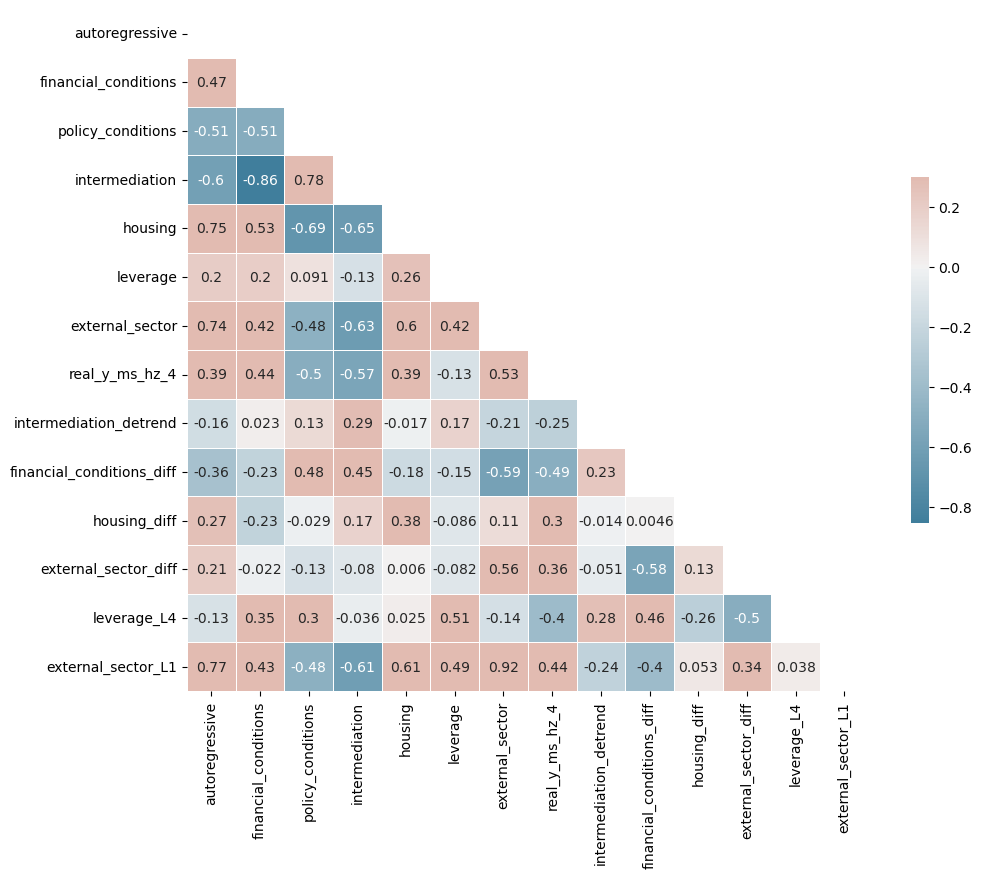

In [4]:
# Compute the correlation matrix
corr = data.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, annot=True,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()

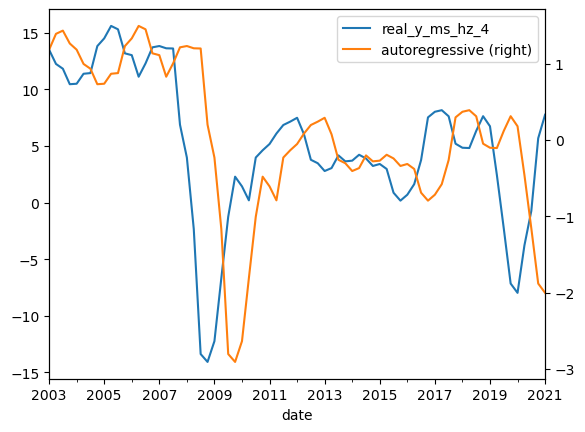

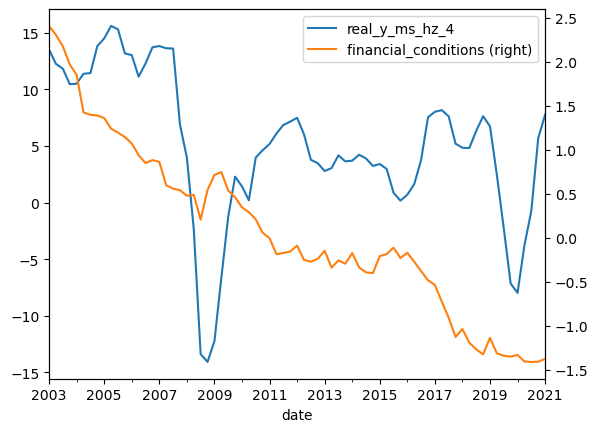

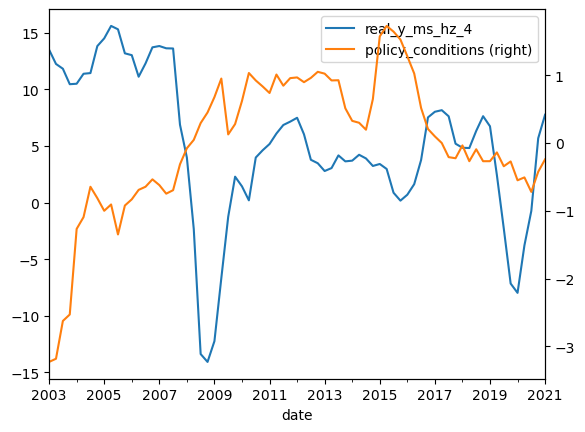

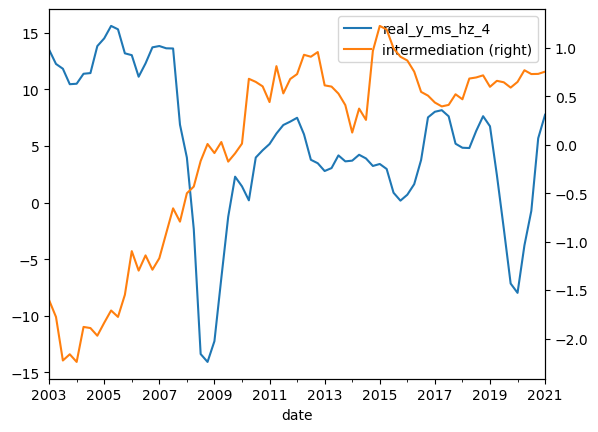

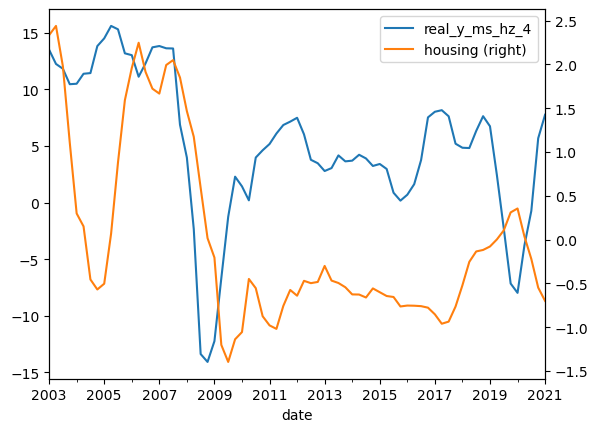

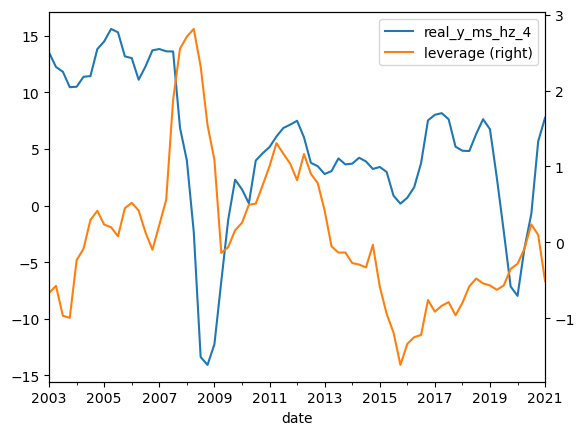

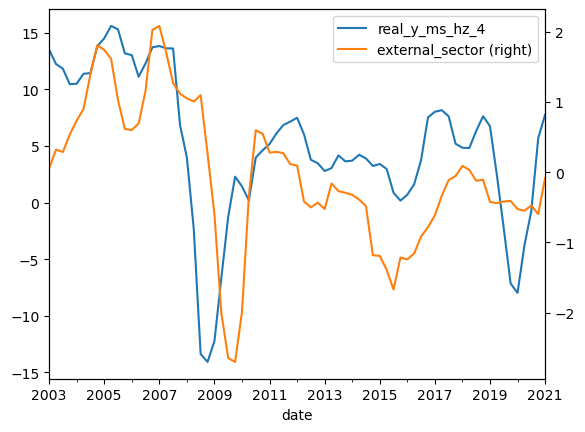

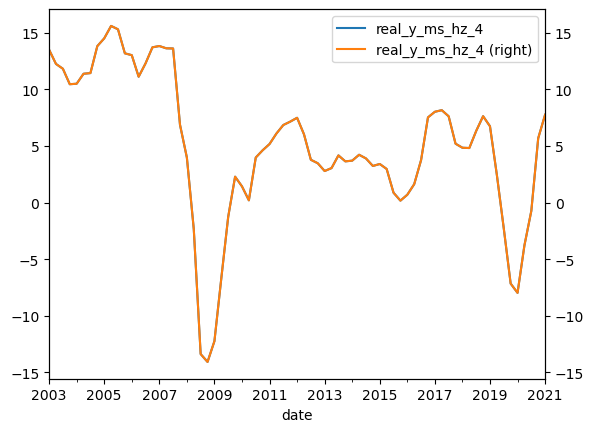

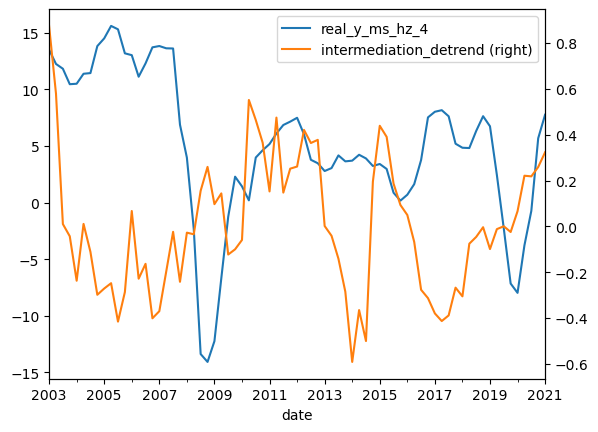

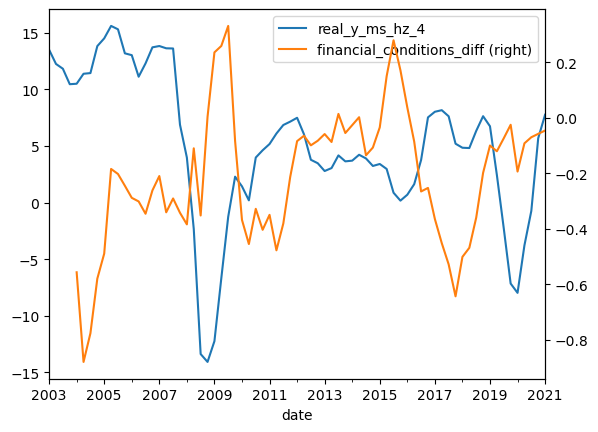

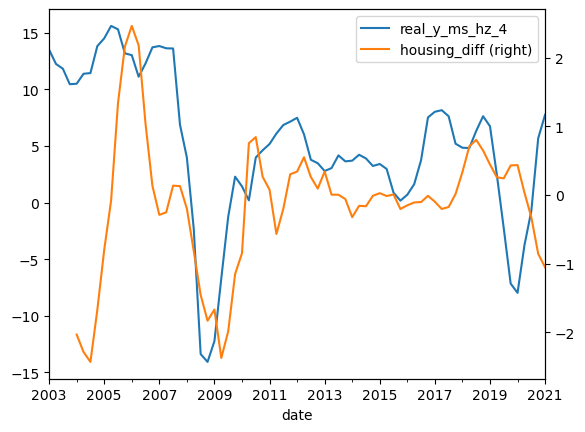

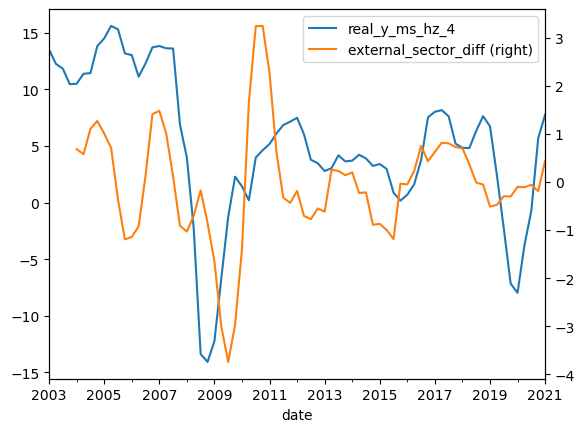

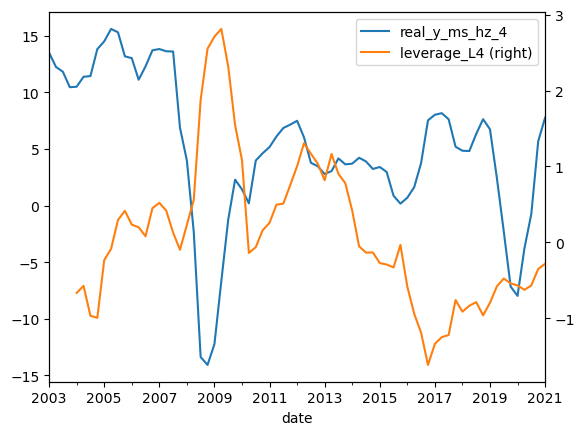

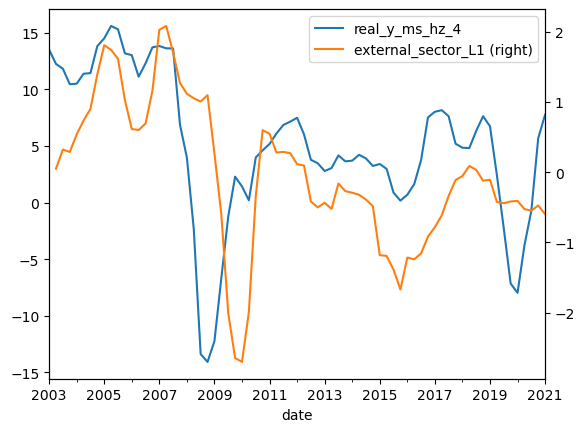

In [5]:
for col in data.columns:
    ax = data.plot(y='real_y_ms_hz_4')
    data.plot(y=col, secondary_y=True, ax=ax)
    plt.show()

# Statistical tests

In [6]:
variable = 'financial_conditions_diff'
res = adfuller(data[variable].dropna(), maxlag=4)
print(f'Adfuller MacKinnon’s approximate p-value: {round(res[1], 5)}')
# print('Null: There is a unit root')
# print('Alternative: There is no unit root')
print(f'Conclusion: {variable} mostly has no unit root')

Adfuller MacKinnon’s approximate p-value: 0.06264
Conclusion: financial_conditions_diff mostly has no unit root


In [7]:
variables = ['real_y_ms_hz_4', 'policy_conditions']
res = coint(data[variables[0]], data[variables[1]], maxlag=4)
print(f'Engle-Granger two-step cointegration test p-value: {round(res[1], 5)}')
# print('Null: There is no cointegration')
# print('Alternative: There is cointegrating relationship')
print(f'Conclusion: {variables[0]} and {variables[1]} have a cointegrating relationship')

Engle-Granger two-step cointegration test p-value: 0.00498
Conclusion: real_y_ms_hz_4 and policy_conditions have a cointegrating relationship


In [8]:
variable = 'intermediation_detrend'
res = adfuller(data[variable].dropna(), maxlag=4)
print(f'Adfuller MacKinnon’s approximate p-value: {round(res[1], 5)}')
# print('Null: There is a unit root')
# print('Alternative: There is no unit root')
print(f'Conclusion: {variable} has no unit root')

Adfuller MacKinnon’s approximate p-value: 0.00146
Conclusion: intermediation_detrend has no unit root


In [9]:
variables = ['real_y_ms_hz_4', 'intermediation_detrend']
res = coint(data[variables[0]], data[variables[1]], maxlag=4)
print(f'Engle-Granger two-step cointegration test p-value: {round(res[1], 5)}')
# print('Null: There is no cointegration')
# print('Alternative: There is cointegrating relationship')
print(f"Conclusion: {variables[0]} and {variables[1]} don't have a cointegrating relationship")

Engle-Granger two-step cointegration test p-value: 0.30583
Conclusion: real_y_ms_hz_4 and intermediation_detrend don't have a cointegrating relationship


In [10]:
variable = 'housing_diff'
res = adfuller(data[variable].dropna(), maxlag=4)
print(f'Adfuller MacKinnon’s approximate p-value: {round(res[1], 5)}')
# print('Null: There is a unit root')
# print('Alternative: There is no unit root')
print(f'Conclusion: {variable} has a unit root')

Adfuller MacKinnon’s approximate p-value: 0.10427
Conclusion: housing_diff has a unit root


In [11]:
variables = ['real_y_ms_hz_4', 'external_sector']
res = coint(data[variables[0]], data[variables[1]], maxlag=4)
print(f'Engle-Granger two-step cointegration test p-value: {round(res[1], 5)}')
# print('Null: There is no cointegration')
# print('Alternative: There is cointegrating relationship')
print(f"Conclusion: {variables[0]} and {variables[1]} don't have a cointegrating relationship")

Engle-Granger two-step cointegration test p-value: 0.45554
Conclusion: real_y_ms_hz_4 and external_sector don't have a cointegrating relationship


# Quantile analysis and OLS fit

In [12]:
data['quantile_segment'] = (data['real_y_ms_hz_4'] <= data['real_y_ms_hz_4'].quantile(0.1)).astype(int)
data['quantile_segment'].replace({0:'no-stress', 1:'stress'}, inplace=True)

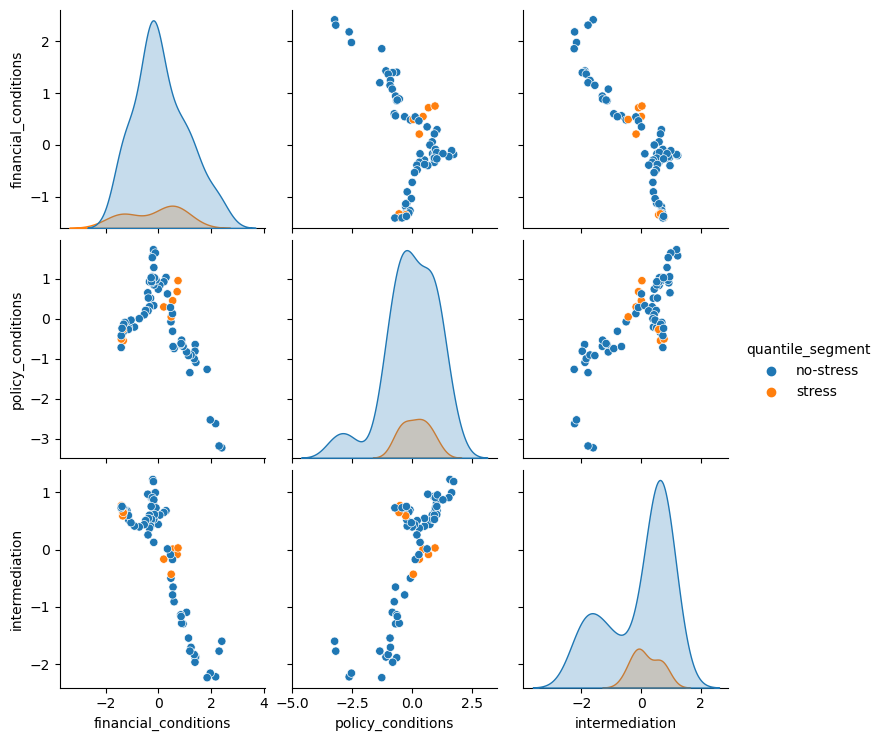

In [13]:
sns.pairplot(data[['financial_conditions', 'policy_conditions', 'intermediation', 'quantile_segment']], 
             hue='quantile_segment')
plt.show()
data = data.drop(columns="quantile_segment")

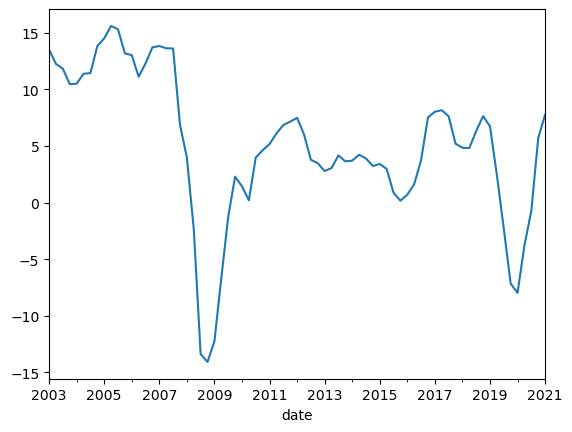

In [14]:
data['real_y_ms_hz_4'].plot()
plt.show()

In [15]:
col_only = ['autoregressive', 'financial_conditions', 'leverage', 'financial_conditions_diff', 
           'housing_diff', 'leverage_L4', 'external_sector_L1']

dataset = data.dropna()
y = dataset['real_y_ms_hz_4']
X_all = sm.add_constant(dataset.drop(columns='real_y_ms_hz_4'))
X_subset = sm.add_constant(dataset.drop(columns='real_y_ms_hz_4')[col_only])

ols_all = sm.OLS(y, X_all, hasconst=True).fit()
ols_sub = sm.OLS(y, X_subset, hasconst=True).fit()

y_hat_all = ols_all.predict(X_all).rename('predictions_with_full_data')
y_hat_subset = ols_sub.predict(X_subset).rename('predictions_with_subset_of_data')
print(f'OLS with full data, R2 adj: {round(ols_all.rsquared_adj, 4)}')
print(f'OLS with a subset data, R2 adj: {round(ols_sub.rsquared_adj, 4)}')

OLS with full data, R2 adj: 0.7272
OLS with a subset data, R2 adj: 0.6592


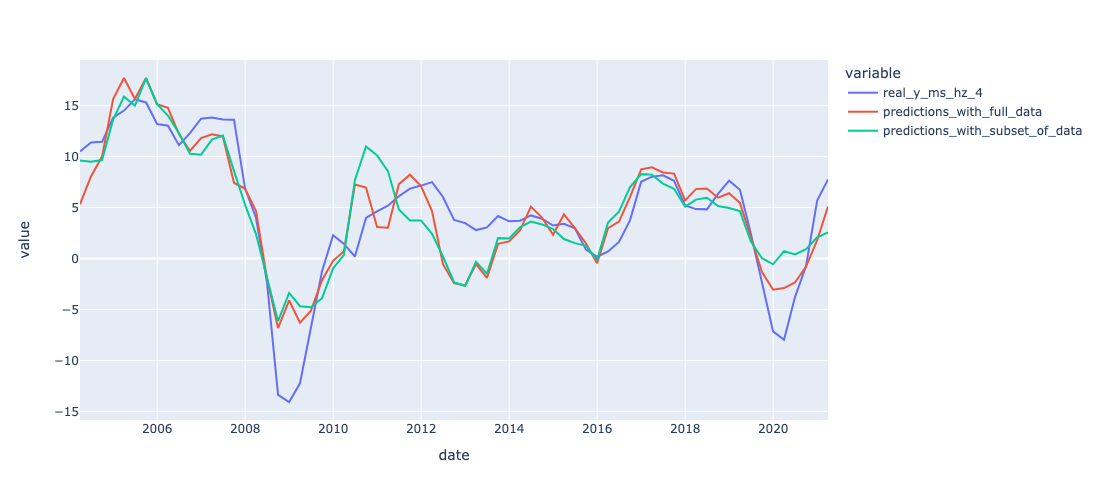

In [16]:
plot_data = pd.concat([y, y_hat_all, y_hat_subset], axis=1)
fig = px.line(plot_data)
fig.show(renderer='png', width=1100, height=500)

In [17]:
models = []
main_cols = []
y = dataset['real_y_ms_hz_4']
for index, col in enumerate(dataset.drop(columns='real_y_ms_hz_4').columns):
    main_cols.append(col)
    X = sm.add_constant(dataset[main_cols])
    ols = sm.OLS(y, X, hasconst=True).fit()
    model = {'index':index, 'model':ols}
    models.append(model)

In [18]:
coef_matrix = pd.DataFrame(models)
coef_matrix = pd.concat([coef_matrix, coef_matrix['model'].apply(lambda x: x.params)], axis=1)
coef_matrix['R2'] = coef_matrix['model'].apply(lambda x: x.rsquared)
coef_matrix['AIC'] = coef_matrix['model'].apply(lambda x: x.aic)

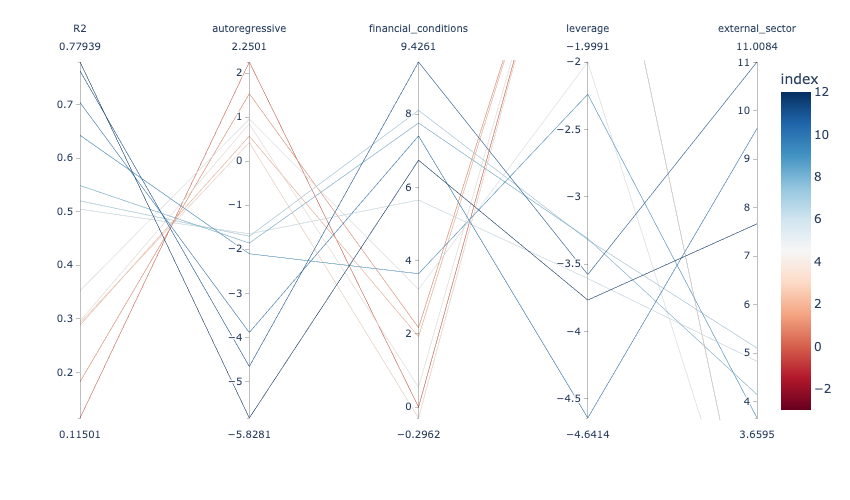

In [19]:
fig = px.parallel_coordinates(coef_matrix, color="index",
                              dimensions=['R2','autoregressive', 'financial_conditions', 'leverage', 'external_sector'],
                              color_continuous_scale=px.colors.diverging.RdBu,
                              color_continuous_midpoint=4.5, width=1200, height=600)
fig.show(renderer='png', width=850, height=500)

In [20]:
# compute the SHAP values for the linear model
explainer_all = shap.Explainer(ols_all.predict, X_all)
shap_values_all = explainer_all(X_all)
X_shap_all = pd.DataFrame(shap_values_all.values, columns=shap_values_all.feature_names, index=y.index)

explainer_subset = shap.Explainer(ols_sub.predict, X_subset)
shap_values_subset = explainer_subset(X_subset)
X_shap_subset = pd.DataFrame(shap_values_subset.values, columns=shap_values_subset.feature_names, index=y.index)

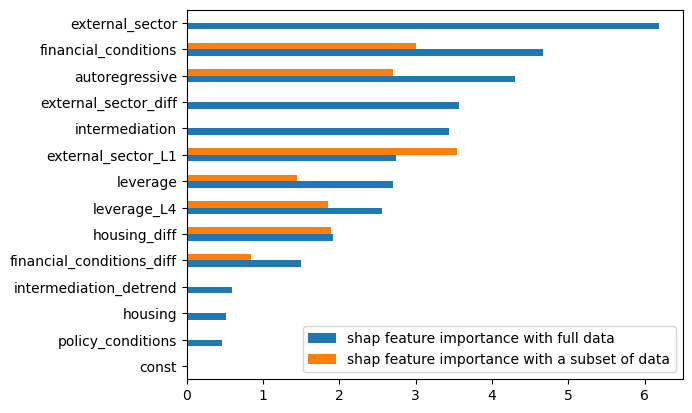

In [21]:
shap_names = {0:'shap feature importance with full data', 1:'shap feature importance with a subset of data'}
shap_feature_importance = pd.concat([X_shap_all.abs().mean(), X_shap_subset.abs().mean()], axis=1)
shap_feature_importance = shap_feature_importance.rename(columns=shap_names).fillna(0)
shap_feature_importance.sort_values('shap feature importance with full data', ascending=True, inplace=True)
shap_feature_importance.plot(kind='barh')
plt.show()

# Quantile regression fit

In [22]:
qmodel_med_all = QuantReg(y, X_all).fit(q=0.5, vcov='robust', kernel='epa', bandwidth='hsheather', max_iter=1000)
qmodel_med_sub = QuantReg(y, X_subset).fit(q=0.5, vcov='robust', kernel='epa', bandwidth='hsheather', max_iter=1000)

y_hat_med_all = qmodel_med_all.predict(X_all).rename('predictions_med_with_full_data')
y_hat_med_sub = qmodel_med_sub.predict(X_subset).rename('predictions_med_with_subset_of_data')

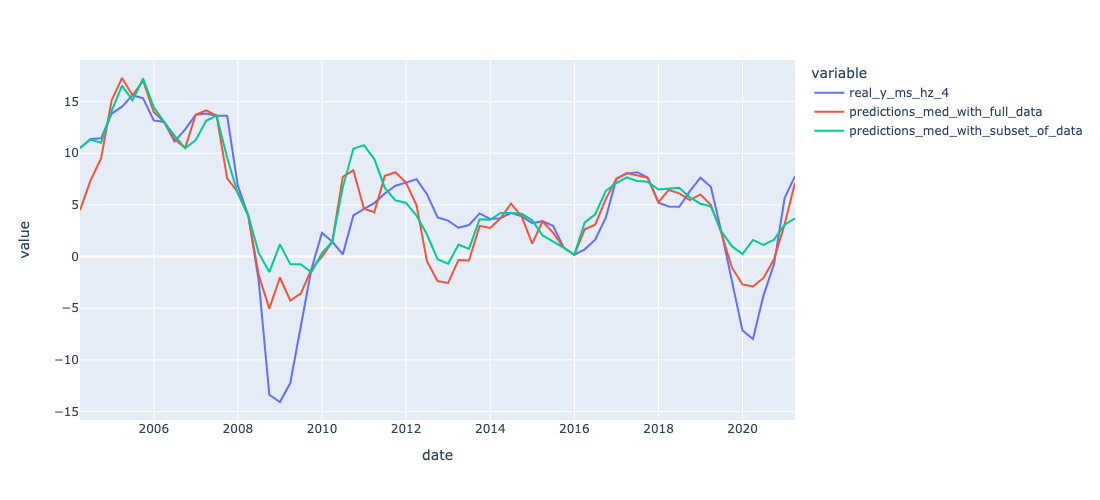

In [23]:
plot_data = pd.concat([y, y_hat_med_all, y_hat_med_sub], axis=1)
fig = px.line(plot_data)
fig.show(renderer='png', width=1100, height=500)

In [24]:
qmodel_tail_all = QuantReg(y, X_all).fit(q=0.1, vcov='robust', kernel='epa', bandwidth='hsheather', max_iter=1000)
qmodel_tail_sub = QuantReg(y, X_subset).fit(q=0.1, vcov='robust', kernel='epa', bandwidth='hsheather', max_iter=1000)

y_hat_tail_all = qmodel_tail_all.predict(X_all).rename('predictions_tail_with_full_data')
y_hat_tail_sub = qmodel_tail_sub.predict(X_subset).rename('predictions_tail_with_subset_of_data')

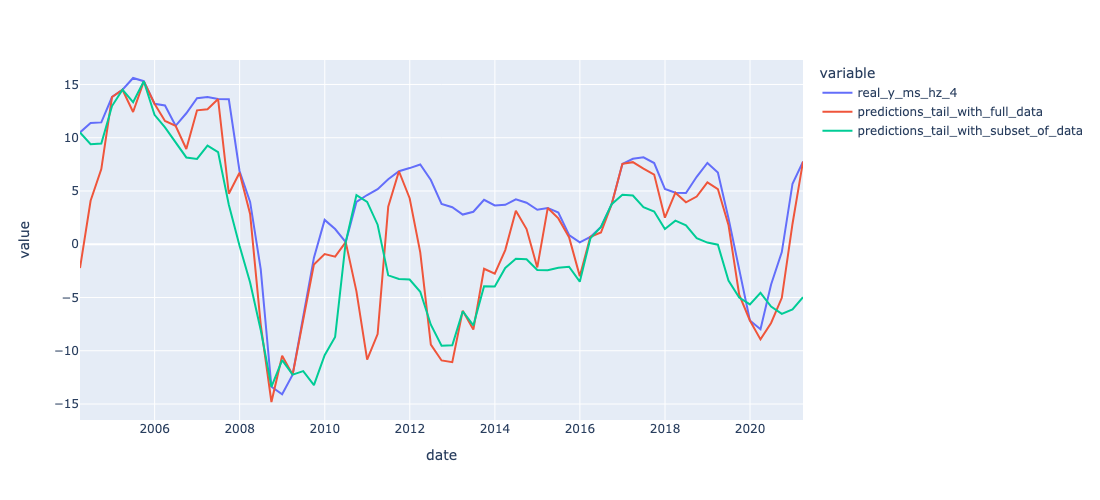

In [25]:
plot_data = pd.concat([y, y_hat_tail_all, y_hat_tail_sub], axis=1)
fig = px.line(plot_data)
fig.show(renderer='png', width=1100, height=500)

# feature selection

In [26]:
col_drop = ['intermediation_detrend','financial_conditions_diff', 
            'housing', 'leverage', 
           'external_sector', 'financial_conditions']
X_choice = X.drop(columns=col_drop)

qmodel_tail_choice = QuantReg(y, X_choice).fit(q=0.1, vcov='robust', kernel='epa', 
                                               bandwidth='hsheather', max_iter=1000)
y_hat_tail_choice = qmodel_tail_choice.predict(X_choice).rename('predictions_tail_with_subset_choice_of_data')

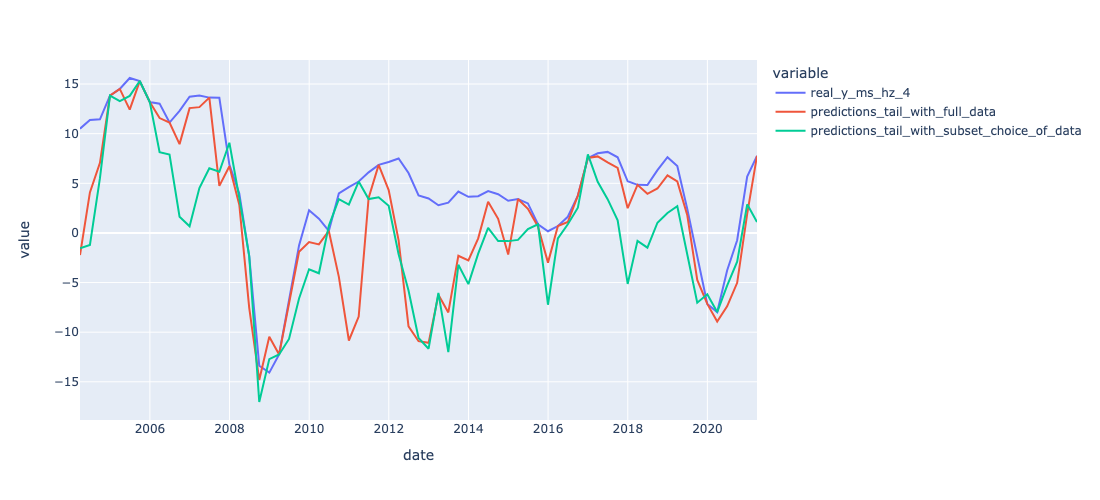

In [27]:
plot_data = pd.concat([y, y_hat_tail_all, y_hat_tail_choice], axis=1)
fig = px.line(plot_data)
fig.show(renderer='png', width=1100, height=500)

In [28]:
q_target = 0.1

# decision function
def r_adj(estimator, X, y):
    return estimator.score(X, y)

# setup model and params
qr = QuantileRegressor(quantile=q_target, alpha=0, fit_intercept=False)

# cross validation generator
tscv = TimeSeriesSplit(n_splits=3, max_train_size=None, test_size=12, gap=0)

# perform feature selection                 
feature_selector = SequentialFeatureSelector(qr, n_features_to_select=9, 
                                             direction='backward', scoring=r_adj, cv=tscv)
feature_selector.fit(X, y)

# X method
X_method = X[feature_selector.get_feature_names_out()]

In [29]:
print('Selected features:')
print(list(feature_selector.get_feature_names_out()))

Selected features:
['const', 'autoregressive', 'policy_conditions', 'intermediation', 'housing', 'housing_diff', 'external_sector_diff', 'leverage_L4', 'external_sector_L1']


In [30]:
qmodel_tail_choice = QuantReg(y, X_choice).fit(q=0.1, vcov='robust', kernel='epa', bandwidth='hsheather', max_iter=2000)
qmodel_tail_method = QuantReg(y, X_method).fit(q=0.1, vcov='robust', kernel='epa', bandwidth='hsheather', max_iter=2000)
model_clean_summary = summary_col([qmodel_tail_choice, qmodel_tail_method], stars=True, 
                            model_names=('Q-choice tail', 'Q-method tail'),
                           info_dict={"R2 Adj.":lambda x:(x.prsquared)})

y_hat_tail_method_choice = qmodel_tail_method.predict(X_method).rename('predictions_tail_method_choice_of_data')

print(model_clean_summary)


                     Q-choice tail Q-method tail
------------------------------------------------
autoregressive       -8.6260***    -7.4829***   
                     (1.4773)      (1.4230)     
const                0.5363        0.3558       
                     (0.7496)      (0.7226)     
external_sector_L1   8.9242***     8.1862***    
                     (1.8312)      (1.7574)     
external_sector_diff -2.6724**     -2.5649**    
                     (1.1394)      (1.0193)     
housing                            -1.4110      
                                   (1.3475)     
housing_diff         4.0512***     4.4124***    
                     (1.1138)      (1.1136)     
intermediation       -8.2119***    -8.2421***   
                     (1.9303)      (1.9221)     
leverage_L4          -7.7090***    -7.1179***   
                     (1.7260)      (1.6085)     
policy_conditions    7.9595***     7.2642***    
                     (2.4748)      (2.4226)     
R2 Adj.            

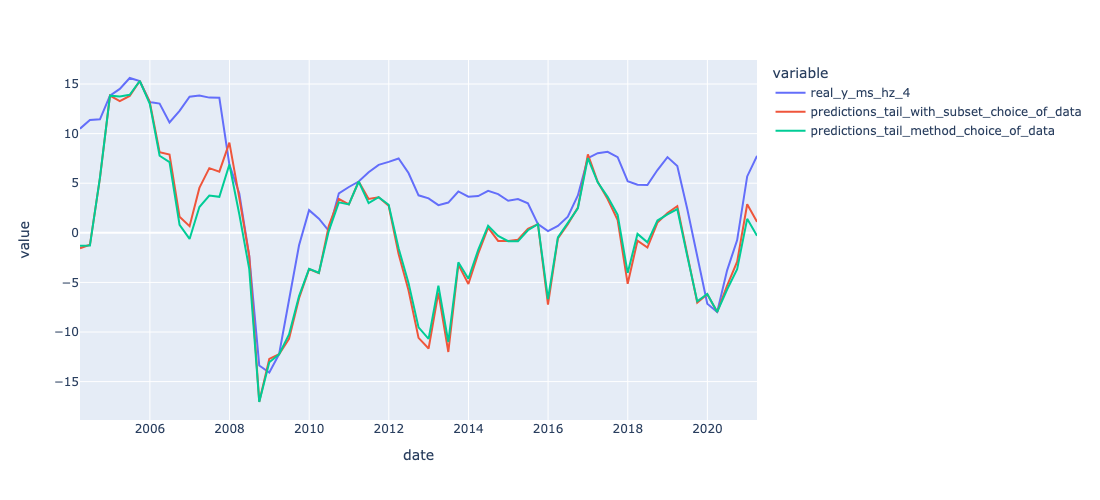

In [31]:
plot_data = pd.concat([y, y_hat_tail_choice, y_hat_tail_method_choice], axis=1)
fig = px.line(plot_data)
fig.show(renderer='png', width=1100, height=500)

In [32]:
qmodel_med_choice = QuantReg(y, X_choice).fit(q=0.5, vcov='robust', kernel='epa', bandwidth='hsheather', max_iter=2000)
qmodel_med_method = QuantReg(y, X_method).fit(q=0.5, vcov='robust', kernel='epa', bandwidth='hsheather', max_iter=2000)
model_clean_summary = summary_col([qmodel_med_choice, qmodel_med_method], stars=True, 
                            model_names=('Q-choice', 'Q-method'),
                           info_dict={"R2 Adj.":lambda x:(x.prsquared)})

y_hat_med_choice = qmodel_med_choice.predict(X_choice).rename('predictions_med_with_subset_choice_of_data')
y_hat_med_method = qmodel_med_method.predict(X_method).rename('predictions_med_method_choice_of_data')

print(model_clean_summary)


                      Q-choice   Q-method 
------------------------------------------
autoregressive       -2.7274*** -2.5162** 
                     (0.9412)   (1.0961)  
const                6.4943***  6.2995*** 
                     (0.4536)   (0.4837)  
external_sector_L1   3.7184***  3.6872*** 
                     (1.0756)   (1.1468)  
external_sector_diff -0.0809    -0.1109   
                     (0.5715)   (0.6120)  
housing                         -0.5571   
                                (0.9948)  
housing_diff         1.7692***  1.8832*** 
                     (0.5402)   (0.6603)  
intermediation       -3.8964*** -3.9188***
                     (0.9054)   (0.9695)  
leverage_L4          -2.4388*** -2.4077***
                     (0.7791)   (0.8629)  
policy_conditions    1.8222     1.7130    
                     (1.1596)   (1.3125)  
R2 Adj.              0.4297     0.4297    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


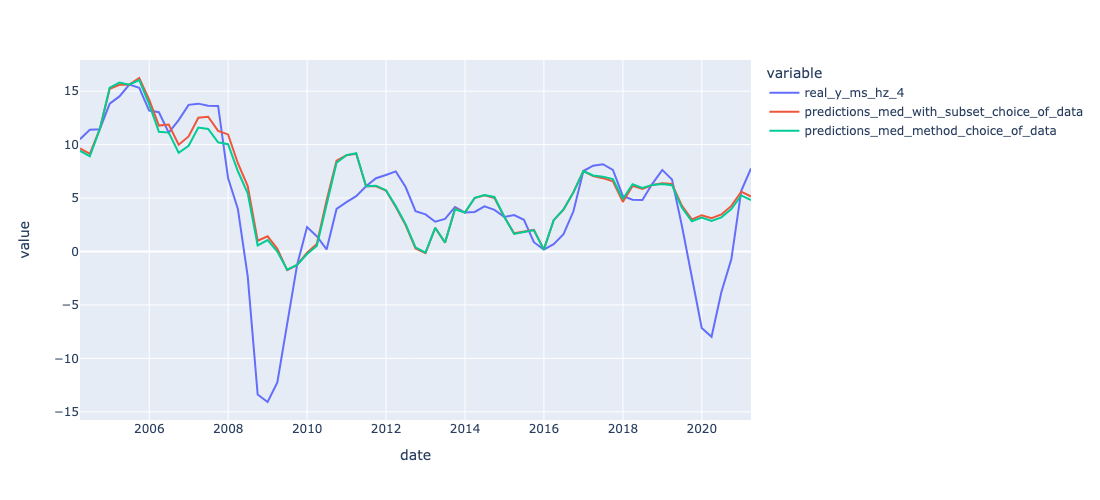

In [33]:
plot_data = pd.concat([y, y_hat_med_choice, y_hat_med_method], axis=1)
fig = px.line(plot_data)
fig.show(renderer='png', width=1100, height=500)

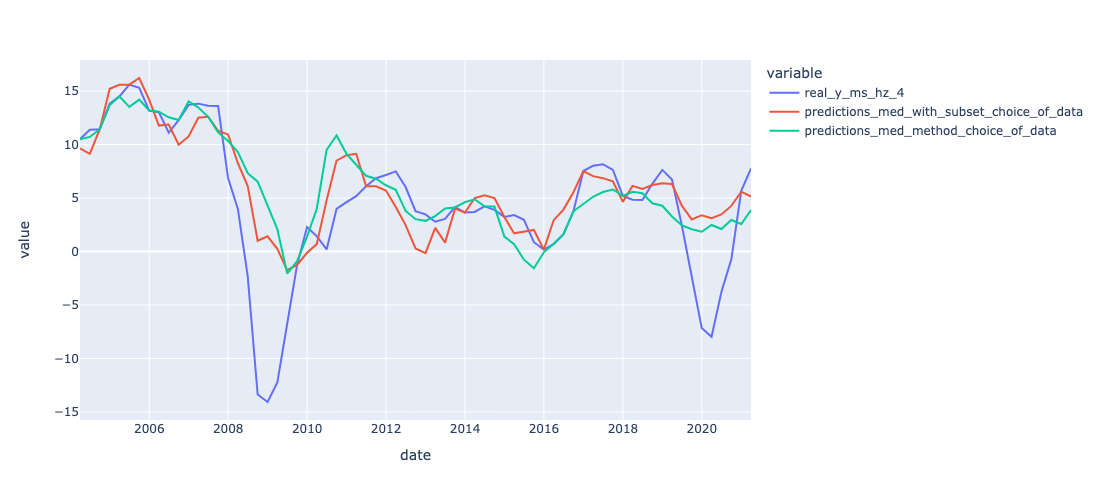

In [223]:
plot_data = pd.concat([y, y_hat_med_choice, y_hat_med_method], axis=1)
fig = px.line(plot_data)
fig.show(renderer='png', width=1100, height=500)

In [34]:
print(f'Choice columns:{list(X_choice.columns)}')
print(f'Method columns:{list(X_method.columns)}')
print(f'Diff columns:{list(set(X_choice.columns) ^ set(X_method.columns))}')

Choice columns:['const', 'autoregressive', 'policy_conditions', 'intermediation', 'housing_diff', 'external_sector_diff', 'leverage_L4', 'external_sector_L1']
Method columns:['const', 'autoregressive', 'policy_conditions', 'intermediation', 'housing', 'housing_diff', 'external_sector_diff', 'leverage_L4', 'external_sector_L1']
Diff columns:['housing']


In [35]:
X_choice.columns

Index(['const', 'autoregressive', 'policy_conditions', 'intermediation',
       'housing_diff', 'external_sector_diff', 'leverage_L4',
       'external_sector_L1'],
      dtype='object')